# 🏖️ Dự Báo Du Lịch Đà Nẵng — TimesFM 2.5

Framework dự báo lượng khách du lịch Đà Nẵng sử dụng **Google TimesFM 2.5** (Google Research, ICML 2024).

**Data sources:** Google Trends + Open-Meteo Weather + Cục Thống kê ĐN + Event Calendar

In [25]:
import sys, os, logging, warnings
sys.path.insert(0, os.getcwd())
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s', datefmt='%H:%M:%S')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.figsize': (14, 6), 'font.size': 11})

print('✅ Imports OK')

✅ Imports OK


## 📡 Step 1: Thu thập dữ liệu

In [26]:
from src.data_collector import collect_all, get_visitor_data, get_event_series, TOURISM_QUERIES, INTL_QUERIES

data = collect_all(start_date='2023-01-01', fetch_trends=True)
print(f"Datasets: {list(data.keys())}")

10:54:27 [INFO] 📡 Fetching weather...
10:54:29 [INFO] ✅ Weather: 1190 days (2023-01-01 → 2026-04-04)
10:54:29 [INFO] 📡 Fetching Google Trends (weekly)...
10:54:30 [INFO] Fetching Google Trends: 'khách sạn đà nẵng' (da_nang_hotel)
10:54:31 [WARNING] Failed 'khách sạn đà nẵng': The request failed: Google returned a response with code 429
10:54:37 [INFO] Fetching Google Trends: 'du lịch đà nẵng' (da_nang_travel)
10:54:38 [WARNING] Failed 'du lịch đà nẵng': The request failed: Google returned a response with code 429
10:54:43 [INFO] Fetching Google Trends: 'vé máy bay đà nẵng' (da_nang_flight)
10:54:46 [WARNING] Failed 'vé máy bay đà nẵng': The request failed: Google returned a response with code 429
10:54:51 [INFO] Fetching Google Trends: 'bà nà hills' (ba_na_hills)
10:54:53 [WARNING] Failed 'bà nà hills': The request failed: Google returned a response with code 429
10:54:58 [INFO] Fetching Google Trends: 'biển mỹ khê' (my_khe_beach)
10:55:00 [WARNING] Failed 'biển mỹ khê': The request fa

Datasets: ['weather', 'trends_weekly', 'visitors', 'events']


### 🌡️ Thời tiết Đà Nẵng

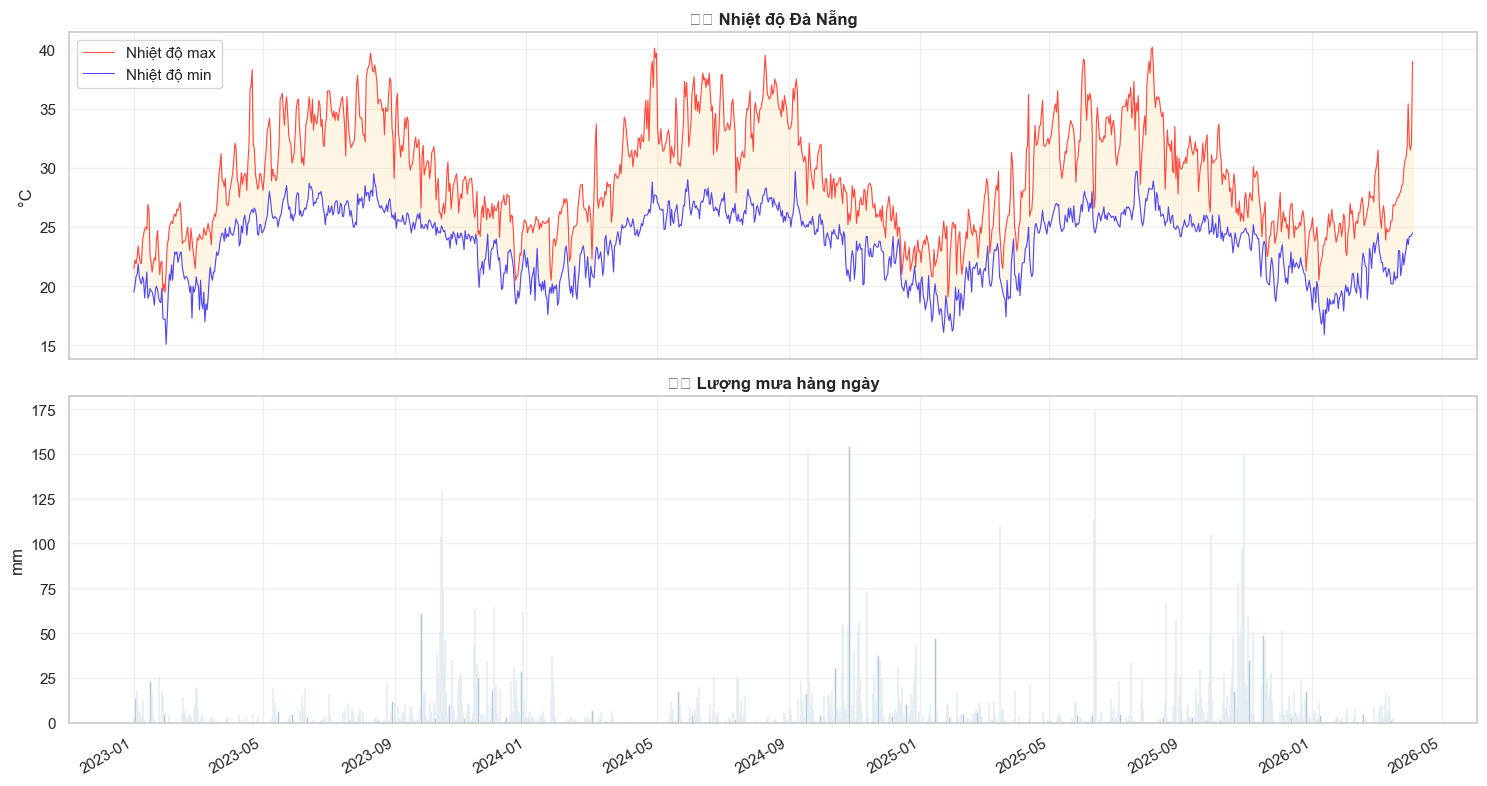

Dữ liệu: 1190 ngày (2023-01-01 → 2026-04-04)


In [27]:
weather = data['weather']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

ax1.plot(weather.index, weather['temp_max'], color='red', alpha=0.7, linewidth=0.8, label='Nhiệt độ max')
ax1.plot(weather.index, weather['temp_min'], color='blue', alpha=0.7, linewidth=0.8, label='Nhiệt độ min')
ax1.fill_between(weather.index, weather['temp_min'], weather['temp_max'], alpha=0.1, color='orange')
ax1.set_ylabel('°C')
ax1.set_title('🌡️ Nhiệt độ Đà Nẵng', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.bar(weather.index, weather['rain'], color='steelblue', alpha=0.6, width=1)
ax2.set_ylabel('mm')
ax2.set_title('🌧️ Lượng mưa hàng ngày', fontweight='bold')
ax2.grid(True, alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print(f"Dữ liệu: {len(weather)} ngày ({weather.index[0].date()} → {weather.index[-1].date()})")

### 🔍 Google Trends — Xu hướng tìm kiếm

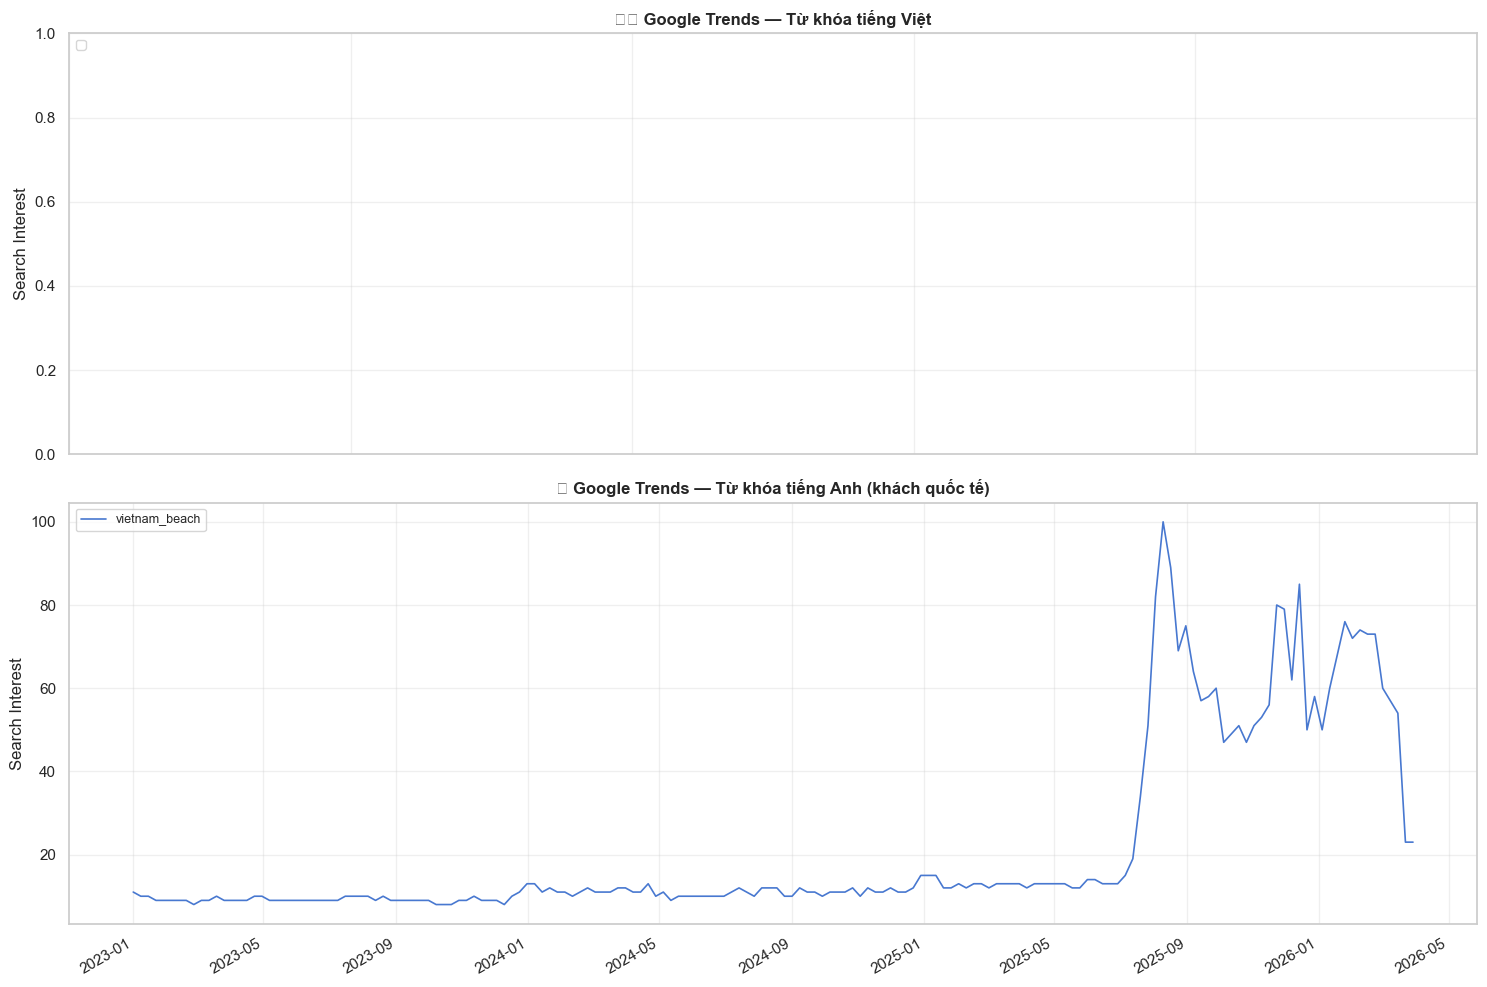

Trends: 170 tuần, 1 queries


In [28]:
if 'trends_weekly' in data:
    trends = data['trends_weekly']
    
    # Chia 2 nhóm: tiếng Việt và tiếng Anh
    vn_cols = [c for c in trends.columns if c in TOURISM_QUERIES]
    en_cols = [c for c in trends.columns if c in INTL_QUERIES or c.endswith('_en')]
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))
    
    for col in vn_cols:
        ax1.plot(trends.index, trends[col], linewidth=1.2, label=col)
    ax1.set_title('🇻🇳 Google Trends — Từ khóa tiếng Việt', fontweight='bold')
    ax1.legend(loc='upper left', fontsize=9)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylabel('Search Interest')
    
    for col in en_cols:
        ax2.plot(trends.index, trends[col], linewidth=1.2, label=col)
    ax2.set_title('🌍 Google Trends — Từ khóa tiếng Anh (khách quốc tế)', fontweight='bold')
    ax2.legend(loc='upper left', fontsize=9)
    ax2.grid(True, alpha=0.3)
    ax2.set_ylabel('Search Interest')
    
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()
    
    print(f"Trends: {len(trends)} tuần, {len(trends.columns)} queries")
else:
    print('⚠️ Google Trends không khả dụng, chạy lại với fetch_trends=True')

### 👥 Lượng khách du lịch hàng tháng

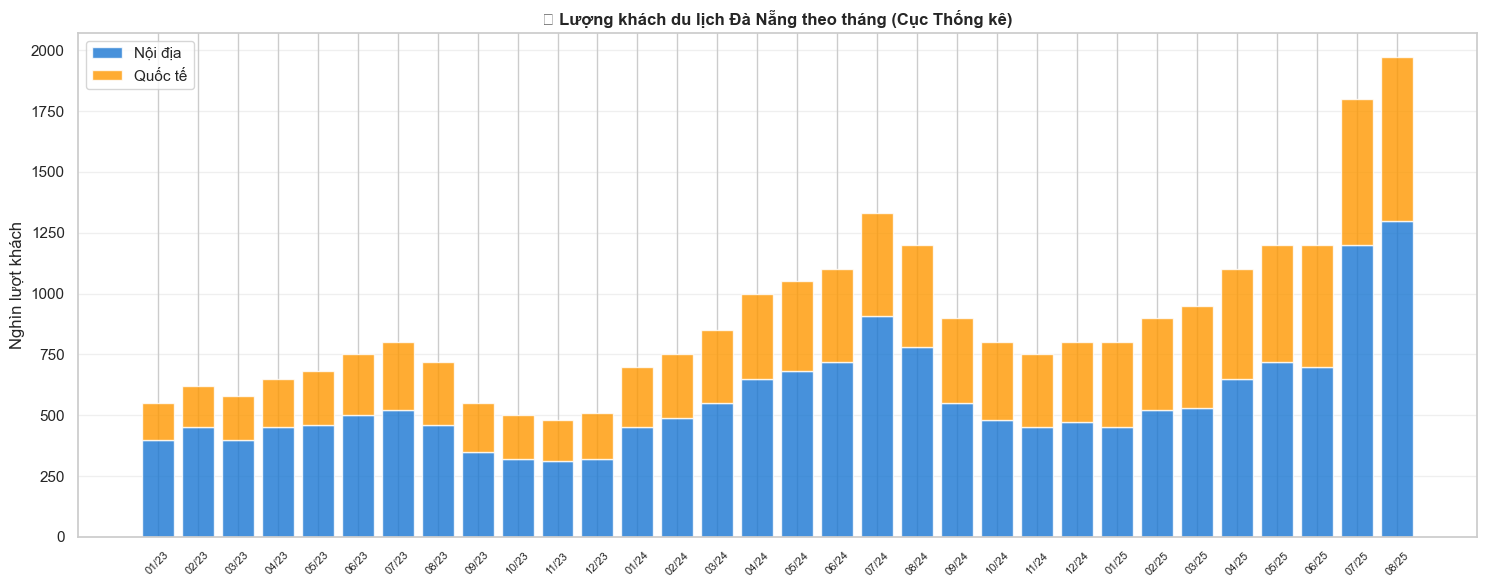

Tổng 2024: 11,200K lượt | 8 tháng 2025: 9,920K lượt


In [29]:
visitors = data['visitors']

fig, ax = plt.subplots(figsize=(15, 6))

x = range(len(visitors))
ax.bar(x, visitors['domestic_visitors_k'], color='#1976D2', alpha=0.8, label='Nội địa')
ax.bar(x, visitors['intl_visitors_k'], bottom=visitors['domestic_visitors_k'], 
       color='#FF9800', alpha=0.8, label='Quốc tế')

ax.set_xticks(x)
ax.set_xticklabels(visitors.index.strftime('%m/%y'), rotation=45, fontsize=8)
ax.set_ylabel('Nghìn lượt khách')
ax.set_title('👥 Lượng khách du lịch Đà Nẵng theo tháng (Cục Thống kê)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

total_2024 = visitors.loc['2024'].total_visitors_k.sum()
total_2025 = visitors.loc['2025'].total_visitors_k.sum()
print(f"Tổng 2024: {total_2024:,.0f}K lượt | 8 tháng 2025: {total_2025:,.0f}K lượt")

## 🧠 Step 2: Load TimesFM 2.5 & Forecast

In [30]:
from src.forecaster import TourismForecaster

forecaster = TourismForecaster(max_context=512, max_horizon=128)
forecaster.load_model()

10:56:21 [INFO] 🔄 Loading TimesFM 2.5...
10:56:21 [INFO] HTTP Request: HEAD https://huggingface.co/google/timesfm-2.5-200m-pytorch/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
10:56:21 [INFO] HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/timesfm-2.5-200m-pytorch/1d952420fba87f3c6dee4f240de0f1a0fbc790e3/config.json "HTTP/1.1 200 OK"
10:56:21 [INFO] Downloading checkpoint from Hugging Face repo google/timesfm-2.5-200m-pytorch
10:56:22 [INFO] HTTP Request: HEAD https://huggingface.co/google/timesfm-2.5-200m-pytorch/resolve/main/model.safetensors "HTTP/1.1 302 Found"
10:56:22 [INFO] Loading checkpoint from: /Users/ngocp/.cache/huggingface/hub/models--google--timesfm-2.5-200m-pytorch/snapshots/1d952420fba87f3c6dee4f240de0f1a0fbc790e3/model.safetensors
10:56:26 [INFO] ✅ Model loaded


### 📈 Forecast Google Trends (12 tuần tới)

In [31]:
HORIZON = 12  # 12 tuần

if 'trends_weekly' in data:
    trends_df = data['trends_weekly']
    series_dict = {col: trends_df[col].dropna().values for col in trends_df.columns if trends_df[col].dropna().shape[0] > 20}
    
    trends_forecasts = forecaster.forecast_multiple(series_dict, horizon=HORIZON)
    
    # Summary table
    summary = []
    for name, r in sorted(trends_forecasts.items(), key=lambda x: x[1].trend_pct, reverse=True):
        emoji = '🟢' if r.trend_pct > 0 else '🔴'
        summary.append({'Query': name, 'Xu hướng': f"{emoji} {r.trend_pct:+.1f}%", 'Last': f"{r.last_value:.0f}", 'Forecast': f"{r.point_forecast[-1]:.0f}"})
    
    summary_df = pd.DataFrame(summary)
    display(summary_df.style.set_caption('📊 Google Trends Forecast — 12 tuần tới').hide(axis='index'))

Query,Xu hướng,Last,Forecast
vietnam_beach,🔴 -21.3%,23,18


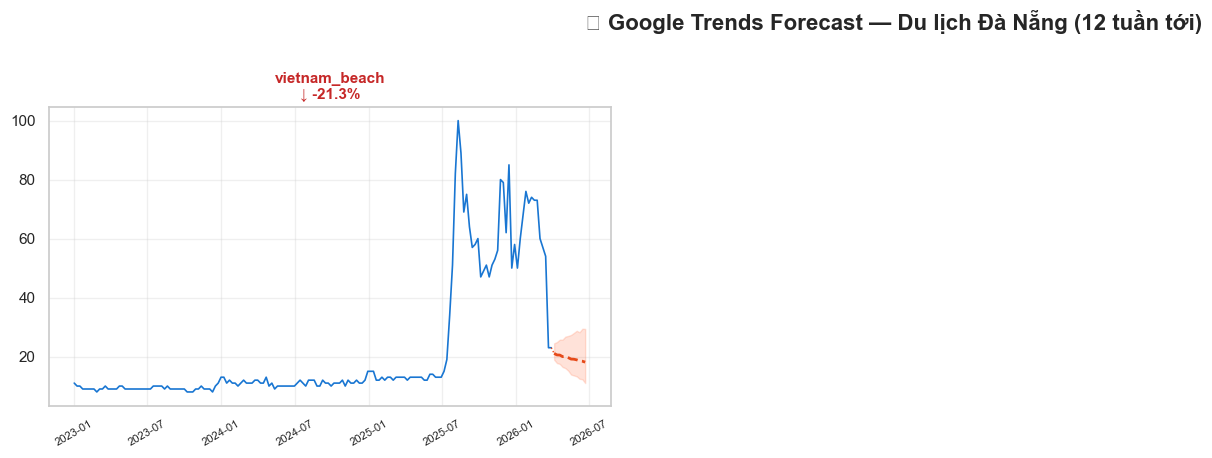

In [32]:
# Charts cho tất cả trends
if 'trends_weekly' in data:
    trends_df = data['trends_weekly']
    events = data.get('events')
    
    n_queries = len(trends_forecasts)
    cols = 3
    rows = (n_queries + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(18, 4.5 * rows))
    axes = axes.flatten()
    
    for idx, (name, result) in enumerate(trends_forecasts.items()):
        ax = axes[idx]
        hist = trends_df[name].dropna()
        
        # History
        ax.plot(hist.index, hist.values, color='#1976D2', linewidth=1.2)
        
        # Forecast
        last_date = hist.index[-1]
        fc_dates = pd.date_range(last_date + pd.Timedelta(weeks=1), periods=result.horizon, freq='W')
        n = min(len(fc_dates), result.horizon)
        
        ax.plot(fc_dates[:n], result.point_forecast[:n], color='#E64A19', linewidth=2, linestyle='--')
        
        # Confidence band
        q = result.quantile_forecast[:n]
        if q.shape[1] >= 10:
            ax.fill_between(fc_dates[:n], q[:, 2], q[:, -2], alpha=0.2, color='#FF7043')
        
        # Connect
        ax.plot([hist.index[-1], fc_dates[0]], [hist.values[-1], result.point_forecast[0]], 
                color='#E64A19', linewidth=1, linestyle=':')
        
        trend = result.trend_pct
        emoji = '↑' if trend > 0 else '↓'
        color = '#2E7D32' if trend > 0 else '#C62828'
        ax.set_title(f"{name}\n{emoji} {trend:+.1f}%", fontweight='bold', color=color, fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=30, labelsize=8)
    
    # Ẩn axes thừa
    for j in range(n_queries, len(axes)):
        axes[j].set_visible(False)
    
    fig.suptitle('🔍 Google Trends Forecast — Du lịch Đà Nẵng (12 tuần tới)', 
                 fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

### 👥 Forecast lượng khách hàng tháng

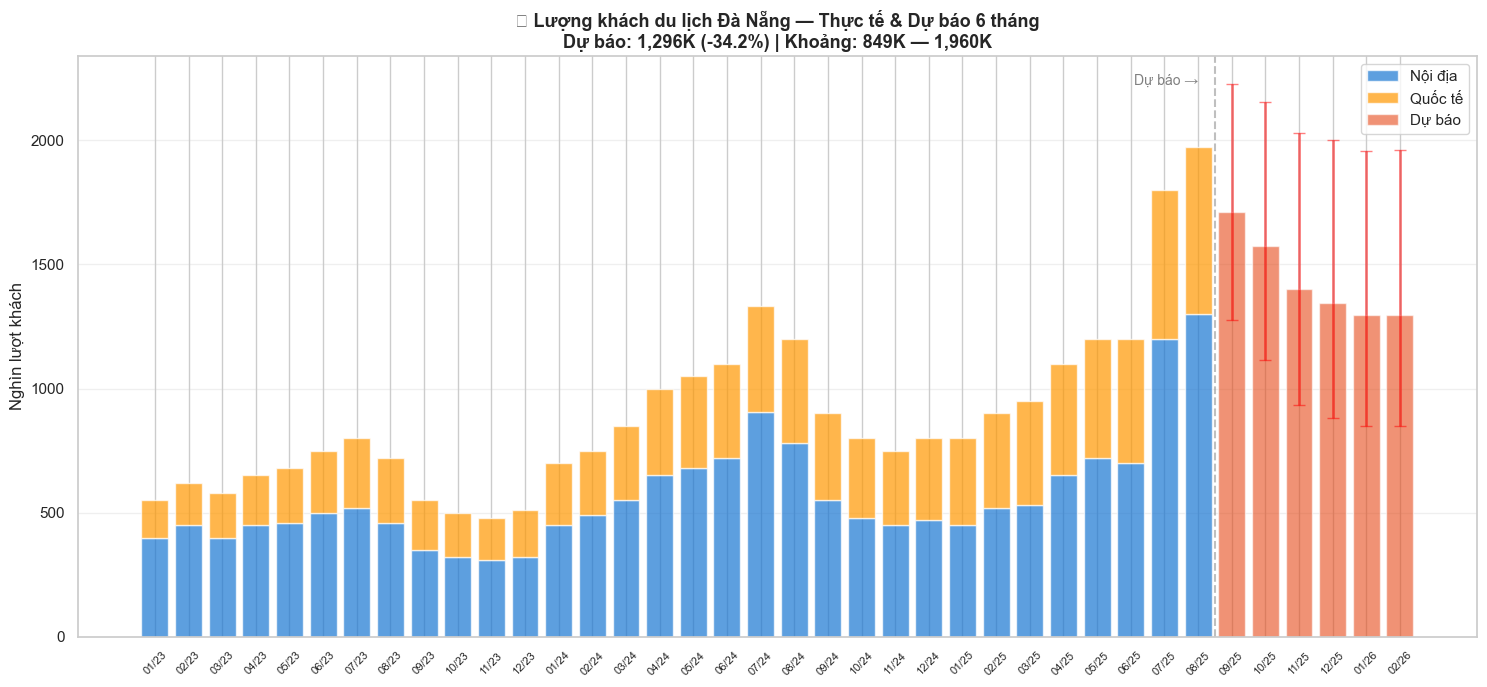

In [33]:
VISITOR_HORIZON = 6  # 6 tháng

visitor_series = visitors['total_visitors_k'].values
visitor_forecast = forecaster.forecast(visitor_series, horizon=VISITOR_HORIZON, name='Khách du lịch ĐN')

fig, ax = plt.subplots(figsize=(15, 7))

# History
x_hist = range(len(visitors))
ax.bar(x_hist, visitors['domestic_visitors_k'], color='#1976D2', alpha=0.7, label='Nội địa')
ax.bar(x_hist, visitors['intl_visitors_k'], bottom=visitors['domestic_visitors_k'],
       color='#FF9800', alpha=0.7, label='Quốc tế')

# Forecast
x_fc = range(len(visitors), len(visitors) + VISITOR_HORIZON)
point = visitor_forecast.point_forecast[:VISITOR_HORIZON]
ax.bar(x_fc, point, color='#E64A19', alpha=0.6, label='Dự báo')

# Error bars
q = visitor_forecast.quantile_forecast[:VISITOR_HORIZON]
if q.shape[1] >= 10:
    lower_err = point - q[:, 1]
    upper_err = q[:, -1] - point
    ax.errorbar(x_fc, point, yerr=[lower_err, upper_err], fmt='none', color='red', alpha=0.5, capsize=4, linewidth=2)

# Labels
all_labels = list(visitors.index.strftime('%m/%y'))
last_date = visitors.index[-1]
for i in range(VISITOR_HORIZON):
    next_m = last_date + pd.DateOffset(months=i+1)
    all_labels.append(next_m.strftime('%m/%y'))

ax.set_xticks(range(len(all_labels)))
ax.set_xticklabels(all_labels, rotation=45, fontsize=8)
ax.set_ylabel('Nghìn lượt khách')
ax.set_title(f'👥 Lượng khách du lịch Đà Nẵng — Thực tế & Dự báo {VISITOR_HORIZON} tháng\n'
             f'Dự báo: {point[-1]:,.0f}K ({visitor_forecast.trend_pct:+.1f}%) | '
             f'Khoảng: {q[-1,1]:,.0f}K — {q[-1,-1]:,.0f}K',
             fontweight='bold', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Divider line
ax.axvline(x=len(visitors)-0.5, color='gray', linestyle='--', alpha=0.5)
ax.text(len(visitors)-1, ax.get_ylim()[1]*0.95, 'Dự báo →', ha='right', fontsize=10, color='gray')

plt.tight_layout()
plt.show()

## 📊 Dashboard Tổng hợp

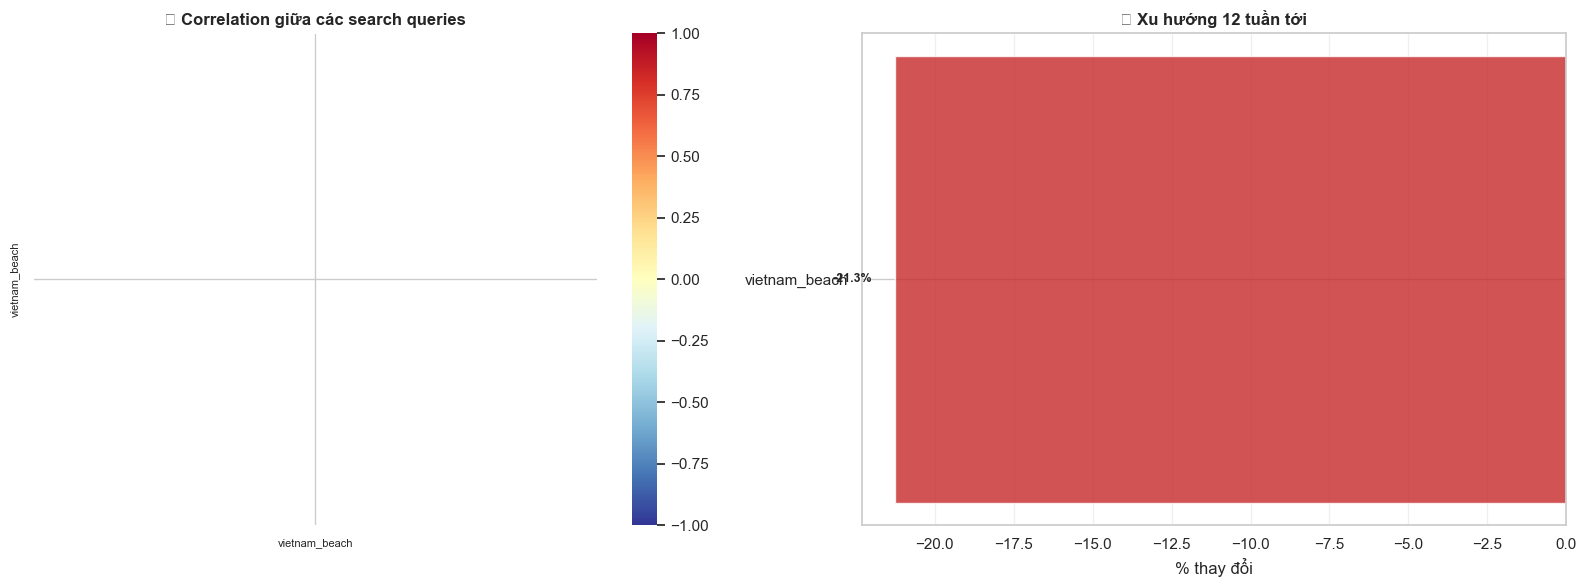

In [34]:
# Heatmap: correlation giữa các trends queries
if 'trends_weekly' in data:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Correlation heatmap
    corr = trends_df.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r', 
                ax=ax1, vmin=-1, vmax=1, linewidths=0.5, annot_kws={'size': 8})
    ax1.set_title('🔗 Correlation giữa các search queries', fontweight='bold')
    ax1.tick_params(axis='both', labelsize=8)
    
    # Forecast trend summary
    names = []
    trends_pct = []
    colors = []
    for name, r in sorted(trends_forecasts.items(), key=lambda x: x[1].trend_pct):
        names.append(name)
        trends_pct.append(r.trend_pct)
        colors.append('#2E7D32' if r.trend_pct > 0 else '#C62828')
    
    ax2.barh(names, trends_pct, color=colors, alpha=0.8)
    ax2.axvline(x=0, color='black', linewidth=0.5)
    ax2.set_xlabel('% thay đổi')
    ax2.set_title('📈 Xu hướng 12 tuần tới', fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='x')
    
    for i, (v, name) in enumerate(zip(trends_pct, names)):
        ax2.text(v + (2 if v > 0 else -2), i, f"{v:+.1f}%", va='center', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

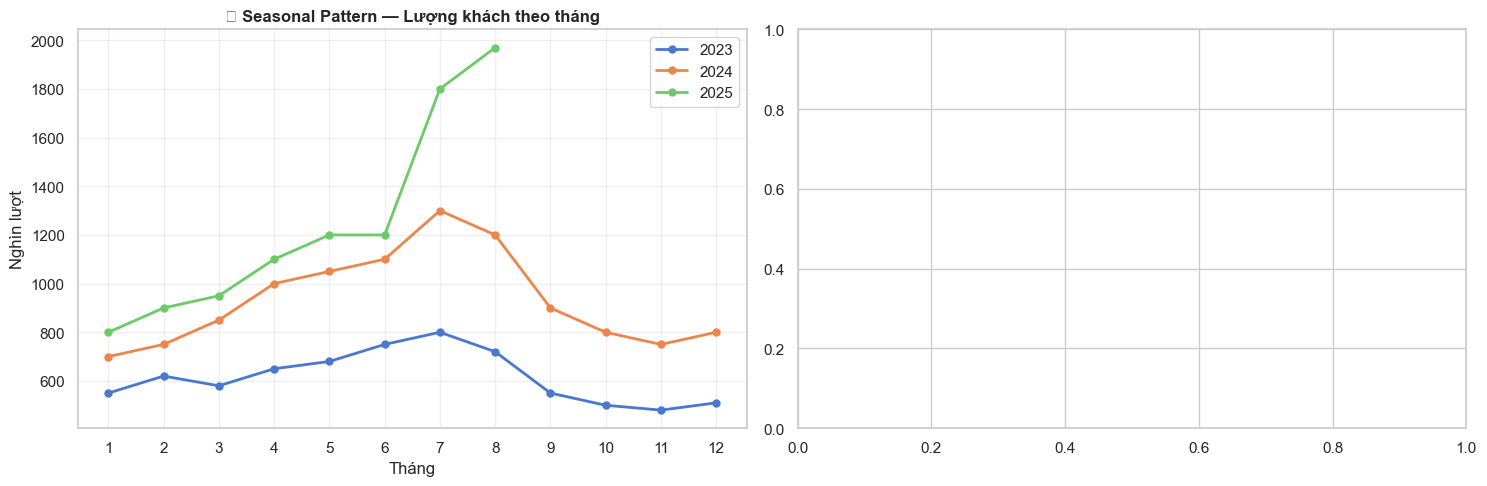

In [35]:
# Seasonality analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Monthly visitor seasonality
visitors_copy = visitors.copy()
visitors_copy['month'] = visitors_copy.index.month
visitors_copy['year'] = visitors_copy.index.year

for year in visitors_copy['year'].unique():
    yr_data = visitors_copy[visitors_copy['year'] == year]
    ax1.plot(yr_data['month'], yr_data['total_visitors_k'], marker='o', linewidth=2, 
             label=str(year), markersize=5)

ax1.set_xlabel('Tháng')
ax1.set_ylabel('Nghìn lượt')
ax1.set_title('📅 Seasonal Pattern — Lượng khách theo tháng', fontweight='bold')
ax1.legend()
ax1.set_xticks(range(1, 13))
ax1.grid(True, alpha=0.3)

# Weather vs Tourism
monthly_weather = weather.resample('ME').agg({'temp_max': 'mean', 'rain': 'sum'})
# Align with visitor data
combined = visitors.join(monthly_weather, how='inner')
if not combined.empty:
    ax2_twin = ax2.twinx()
    ax2.bar(range(len(combined)), combined['rain'], color='steelblue', alpha=0.4, label='Mưa (mm)')
    ax2_twin.plot(range(len(combined)), combined['total_visitors_k'], color='#E64A19', 
                  linewidth=2, marker='o', markersize=4, label='Khách (K)')
    ax2.set_title('🌧️ Mưa vs Lượng khách', fontweight='bold')
    ax2.set_ylabel('Lượng mưa (mm)')
    ax2_twin.set_ylabel('Nghìn lượt khách')
    ax2.legend(loc='upper left')
    ax2_twin.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 💡 Nhận định & Khuyến nghị

In [36]:
if trends_forecasts:
    vn_trends = {k: v for k, v in trends_forecasts.items() if not k.endswith('_en')}
    en_trends = {k: v for k, v in trends_forecasts.items() if k.endswith('_en')}
    
    avg_vn = np.mean([r.trend_pct for r in vn_trends.values()]) if vn_trends else 0
    avg_en = np.mean([r.trend_pct for r in en_trends.values()]) if en_trends else 0
    avg_all = np.mean([r.trend_pct for r in trends_forecasts.values()])
    
    print('=' * 60)
    print('📊 TỔNG HỢP DỰ BÁO DU LỊCH ĐÀ NẴNG')
    print('=' * 60)
    print()
    print(f'🇻🇳 Xu hướng nội địa (TB):  {avg_vn:+.1f}%')
    print(f'🌍 Xu hướng quốc tế (TB):  {avg_en:+.1f}%')
    print(f'📈 Xu hướng chung (TB):     {avg_all:+.1f}%')
    print()
    print(f'👥 Lượng khách gần nhất:    {visitor_forecast.last_value:,.0f}K lượt')
    print(f'🔮 Dự báo +{VISITOR_HORIZON} tháng:       {visitor_forecast.point_forecast[-1]:,.0f}K lượt ({visitor_forecast.trend_pct:+.1f}%)')
    print(f'📐 Khoảng tin cậy:          {visitor_forecast.lower_10[-1]:,.0f}K — {visitor_forecast.upper_90[-1]:,.0f}K')
    print()
    print('─' * 60)
    print('💡 KHUYẾN NGHỊ:')
    print('─' * 60)
    if avg_vn > 20:
        print('🟢 Nội địa TĂNG MẠNH → Chuẩn bị cho mùa cao điểm')
        print('   • Tăng giá phòng 10-20% cho peak season')
        print('   • Tuyển thêm nhân viên seasonal')
        print('   • Stock up nguyên liệu F&B')
    elif avg_vn > 0:
        print('🟡 Nội địa tăng nhẹ → Duy trì bình thường')
    else:
        print('🔴 Nội địa giảm → Cần kích cầu')
    
    if avg_en < -10:
        print(f'\n⚠️  Khách quốc tế giảm ({avg_en:+.1f}%)')
        print('   • Có thể do căng thẳng địa chính trị (Iran)')
        print('   • Focus marketing sang thị trường châu Á (Hàn, Nhật, Ấn Độ)')
        print('   • Tăng promo trên Booking.com, Agoda cho thị trường mục tiêu')
    elif avg_en > 10:
        print(f'\n✈️  Khách quốc tế tăng tốt ({avg_en:+.1f}%)')
    
    print()
    print('⚠️  Lưu ý: Dự báo mang tính tham khảo, cần kết hợp phân tích định tính.')

📊 TỔNG HỢP DỰ BÁO DU LỊCH ĐÀ NẴNG

🇻🇳 Xu hướng nội địa (TB):  -21.3%
🌍 Xu hướng quốc tế (TB):  +0.0%
📈 Xu hướng chung (TB):     -21.3%

👥 Lượng khách gần nhất:    1,970K lượt
🔮 Dự báo +6 tháng:       1,296K lượt (-34.2%)
📐 Khoảng tin cậy:          849K — 1,960K

────────────────────────────────────────────────────────────
💡 KHUYẾN NGHỊ:
────────────────────────────────────────────────────────────
🔴 Nội địa giảm → Cần kích cầu

⚠️  Lưu ý: Dự báo mang tính tham khảo, cần kết hợp phân tích định tính.


---
**Powered by:** [TimesFM 2.5](https://github.com/google-research/timesfm) (Google Research) | Data: Google Trends + Open-Meteo + Cục Thống kê Đà Nẵng